In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(801, 597, 3)


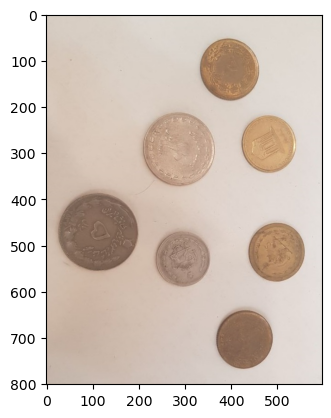

In [41]:
image = cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/old-iranian-coins.jpg")
print(image.shape)

plt.imshow(image[..., ::-1]);

(801, 597)


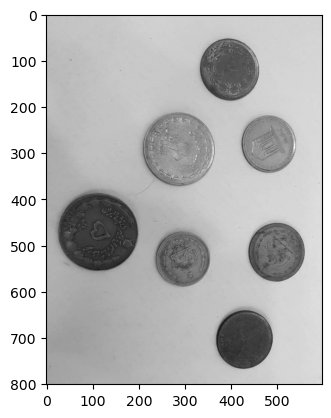

In [42]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print(image_gray.shape)

plt.imshow(image_gray, cmap='gray')

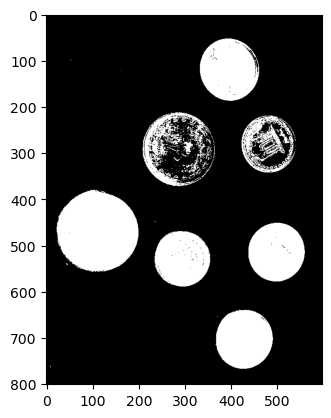

In [43]:
ret, thresh = cv2.threshold(image_gray, 170, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh, cmap='gray')

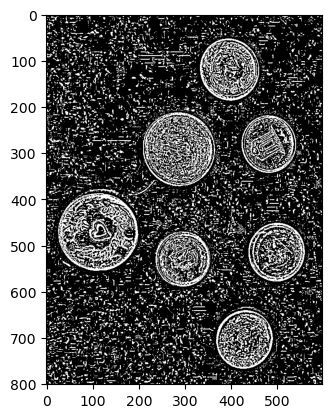

In [44]:
threshold = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 1)

plt.imshow(threshold, cmap='gray')

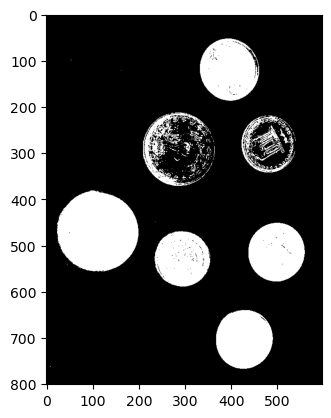

In [45]:
_, image_thresh = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(image_thresh, cmap='gray')

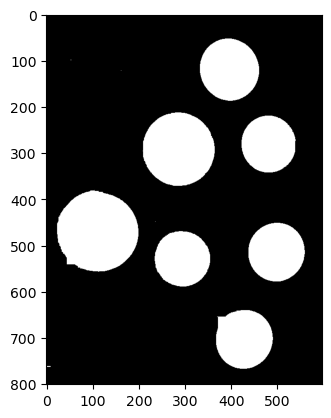

In [46]:
closed_image = cv2.morphologyEx(image_thresh, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25)))
plt.imshow(closed_image, cmap='gray')

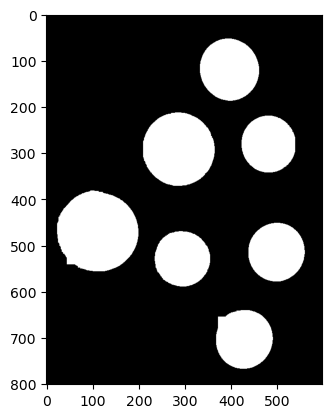

In [47]:
opened_image = cv2.morphologyEx(closed_image, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)))
plt.imshow(opened_image, cmap='gray')

In [49]:
contours, hierarchy = cv2.findContours(opened_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
print(len(contours))


7


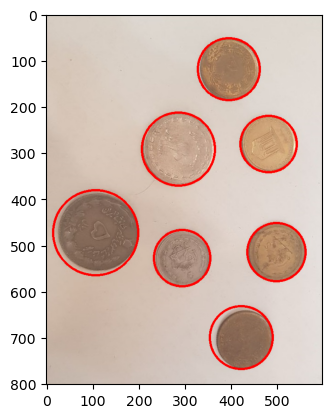

In [55]:
image_copy = image.copy()

for contour in contours:
    if contour.shape[0] > 50:
        center, radius = cv2.minEnclosingCircle(contour)

        center = (int(center[0]), int(center[1]))
        radius = int(radius)

        cv2.circle(image_copy, center=center, radius=radius, color=(0, 0, 255), thickness=3)

plt.imshow(image_copy[..., ::-1]);
        

In [53]:
center[0]

422.3664855957031

In [54]:
center[1]

700.7179565429688